# Netflix Content Analysis: Exploratory Data Analysis (EDA)

## Project Overview

Netflix hosts thousands of movies and TV shows from around the world. Understanding the distribution of content, growth trends, ratings, and genre preferences can provide valuable insights into content strategy and audience targeting.

This project performs a comprehensive Exploratory Data Analysis (EDA) on Netflix's content catalog using Python and data visualization techniques.

## Business Problem

Netflix continuously expands its content library across multiple countries and genres.

This analysis aims to answer:

1. What type of content dominates Netflix?
2. Which countries contribute the most content?
3. How has Netflix's catalog evolved over time?
4. Which audience ratings are most common?
5. What genres are most prevalent?

## Dataset Description

The dataset contains metadata for Netflix movies and TV shows including:

- Title
- Type
- Director
- Cast
- Country
- Release Year
- Date Added
- Rating
- Duration
- Genre

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")


In [88]:
df = pd.read_csv('netflix_titles.csv')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


## Data Understanding

Before analysis, we inspect the dataset structure, data types, and completeness of information.

In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [90]:
df.shape

(8807, 12)

In [91]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [92]:
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [93]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

### Observation

Several columns contain missing values, particularly Director, Cast, and Country.
These columns require cleaning before analysis.

# Data Cleaning

## Missing Value Analysis

In [94]:
print((df.isnull().sum() / len(df) * 100).round(2))

show_id          0.00
type             0.00
title            0.00
director        29.91
cast             9.37
country          9.44
date_added       0.11
release_year     0.00
rating           0.05
duration         0.03
listed_in        0.00
description      0.00
dtype: float64


### Findings

Director, Cast, and Country contain missing values.

To maintain dataset consistency, missing entries are replaced with 'Unknown' where appropriate.

In [95]:
df['director'] = df['director'].fillna('Unknown')
df['cast']     = df['cast'].fillna('Unknown')
df['country']  = df['country'].fillna('Unknown')
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           4
duration         3
listed_in        0
description      0
dtype: int64

In [96]:
df.dropna(subset=['date_added', 'rating','duration'], inplace=True)
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

## Feature Engineering

Additional temporal features are extracted from the Date Added column to analyze content trends over time.

In [97]:
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], format='%B %d, %Y')

df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [98]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['month_name'] = df['date_added'].dt.strftime('%b')

df.head(3)[['title', 'date_added', 'year_added', 'month_added']]

,title,date_added,year_added,month_added
0,Dick Johnson Is Dead,2021-09-25,2021,9
1,Blood & Water,2021-09-24,2021,9
2,Ganglands,2021-09-24,2021,9


## Analysis 1: Movies vs TV Shows

### Question

How is Netflix's content divided between Movies and TV Shows?

In [99]:
movies = df[df['type'] == 'Movie'].copy()
shows  = df[df['type'] == 'TV Show'].copy()

movies['duration_min'] = movies['duration'].str.replace(' min', '').astype(int)
shows['duration_seasons'] = shows['duration'].str.replace(' Season', '').str.replace('s', '').astype(int)

print("Movie duration stats (minutes):")
print(movies['duration_min'].describe())
print("\nTV Show seasons stats:")
print(shows['duration_seasons'].describe())

Movie duration stats (minutes):
count    6126.000000
mean       99.584884
std        28.283225
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_min, dtype: float64

TV Show seasons stats:
count    2664.000000
mean        1.751877
std         1.550622
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: duration_seasons, dtype: float64


In [100]:
type_counts = df['type'].value_counts()
print(type_counts)

type
Movie      6126
TV Show    2664
Name: count, dtype: int64


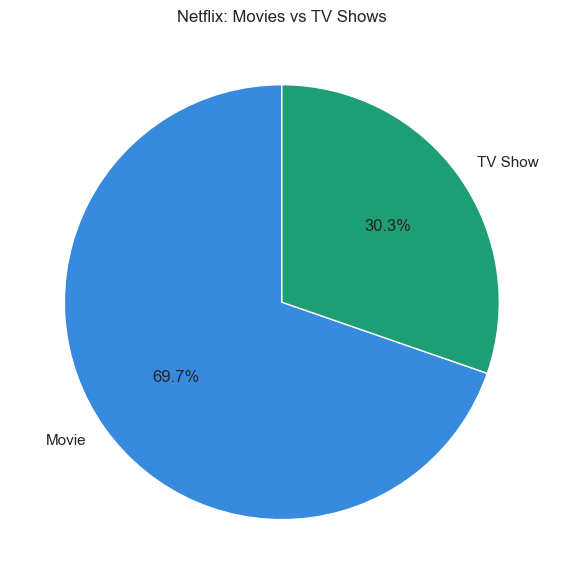

In [101]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    colors=['#378ADD', '#1D9E75'],
    startangle=90,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)
ax.set_title('Netflix: Movies vs TV Shows')
plt.tight_layout()
plt.show()

### Observation

Movies significantly outnumber TV Shows.

### Business Insight

Netflix appears to prioritize movie content acquisition and production, likely due to broader audience reach and lower long-term commitment compared to TV series.

## Analysis 2: Ratings Distribution

### Question

What types of audience ratings dominate Netflix's content catalog?

### Objective

To understand the target audience demographics of Netflix content.

In [102]:
rating_counts = df['rating'].value_counts()
rating_counts


rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

[Text(0, 3, '3205'),
 Text(0, 3, '2157'),
 Text(0, 3, '861'),
 Text(0, 3, '799'),
 Text(0, 3, '490'),
 Text(0, 3, '333'),
 Text(0, 3, '306'),
 Text(0, 3, '287'),
 Text(0, 3, '220'),
 Text(0, 3, '79'),
 Text(0, 3, '41'),
 Text(0, 3, '6'),
 Text(0, 3, '3'),
 Text(0, 3, '3')]

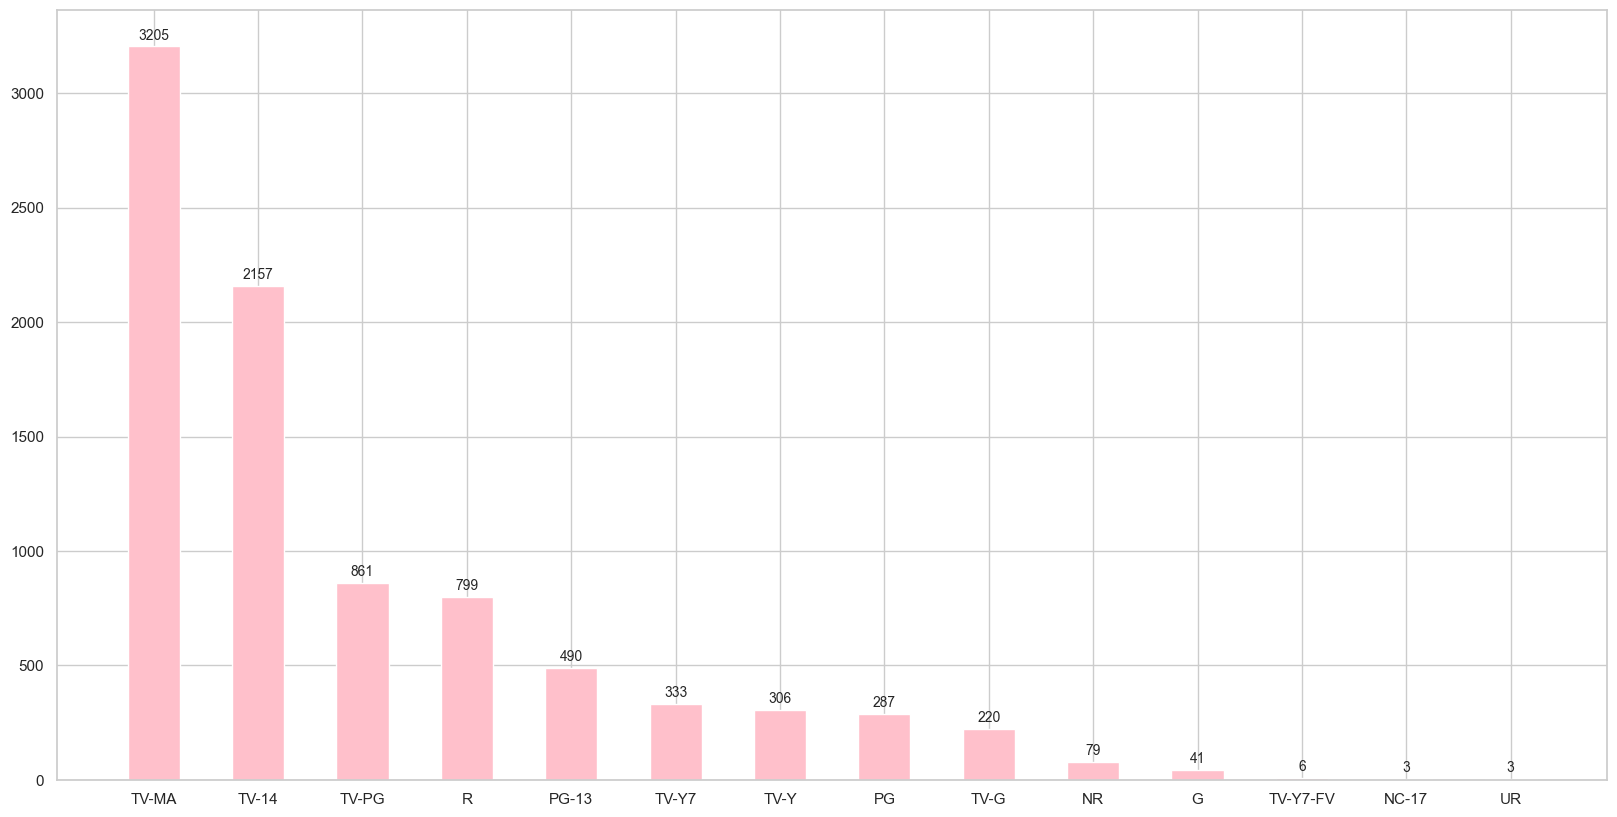

In [103]:
fig2, ax = plt.subplots(figsize=(20, 10))
bars=ax.bar(rating_counts.index,rating_counts.values,color='pink',width=0.5)
ax.bar_label(bars,padding=3, fontsize=10)


### Observation

- TV-MA is the most frequently occurring rating.

### Insight

Netflix primarily targets adult audiences while still maintaining a diverse range of content for other age groups.

## Analysis 3: Country-wise Content Distribution

### Question

Which countries contribute the most content to Netflix?

### Objective

To identify the major content-producing countries represented on the platform.

In [104]:
country_counts=(df['country'].str.split(',').explode().str.strip().value_counts().drop('Unknown').head(10))
country_counts

country
United States     3681
India             1046
United Kingdom     805
Canada             445
France             393
Japan              316
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

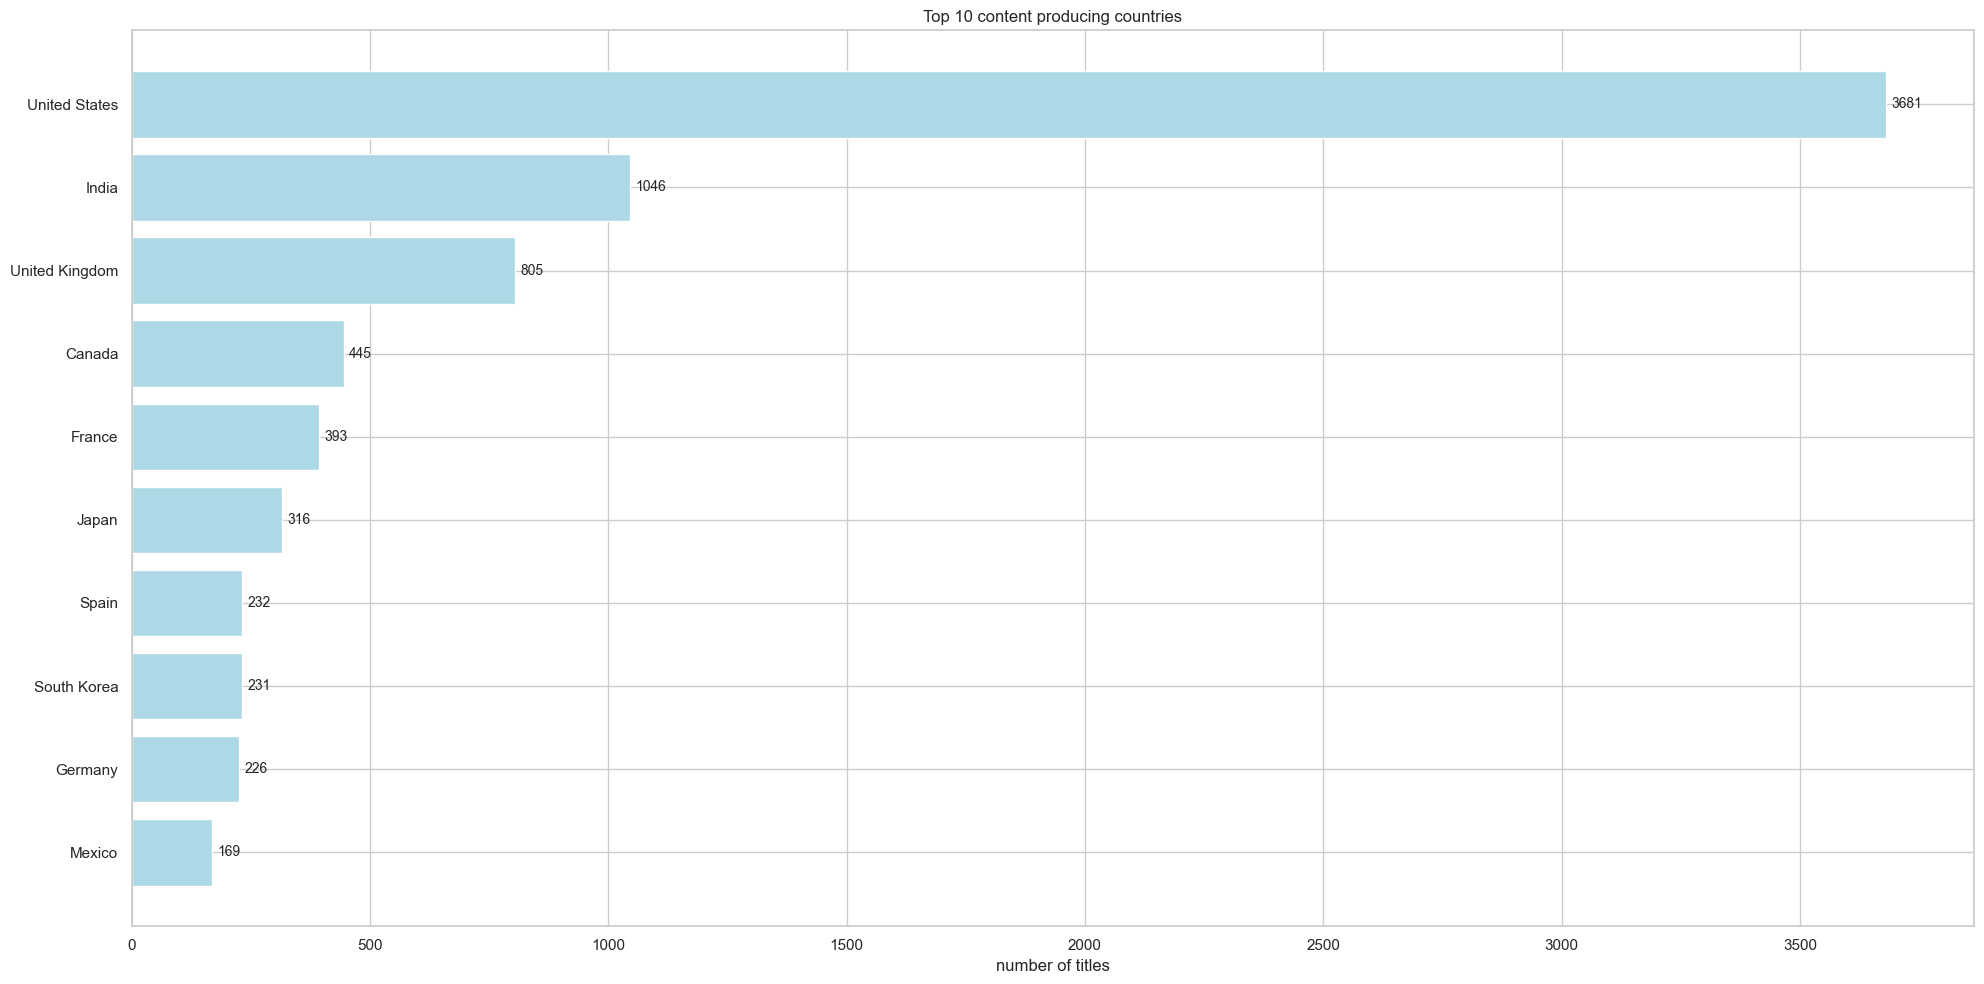

In [105]:
fig3,ax=plt.subplots(figsize=(20,10))
bars=ax.barh(country_counts.index[::-1],country_counts.values[::-1],color='lightblue')
ax.bar_label(bars, padding=4,fontsize=10)
ax.set_title('Top 10 content producing countries')
ax.set_xlabel("number of titles")
plt.tight_layout()
plt.show()

### Observation

- The United States contributes the highest number of titles.
- India ranks among the leading content-producing countries.
- Several countries contribute significantly to Netflix's international catalog.

### Insight

Netflix maintains a strong global presence while relying heavily on content from a few major production markets.

## Analysis 4: Genre Analysis

### Question

Which genres are most common on Netflix?

### Objective

To identify the genres that dominate Netflix's content library.

In [106]:
genres=df['listed_in'].str.split(',').explode().str.strip().value_counts().head(10)

genres

listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

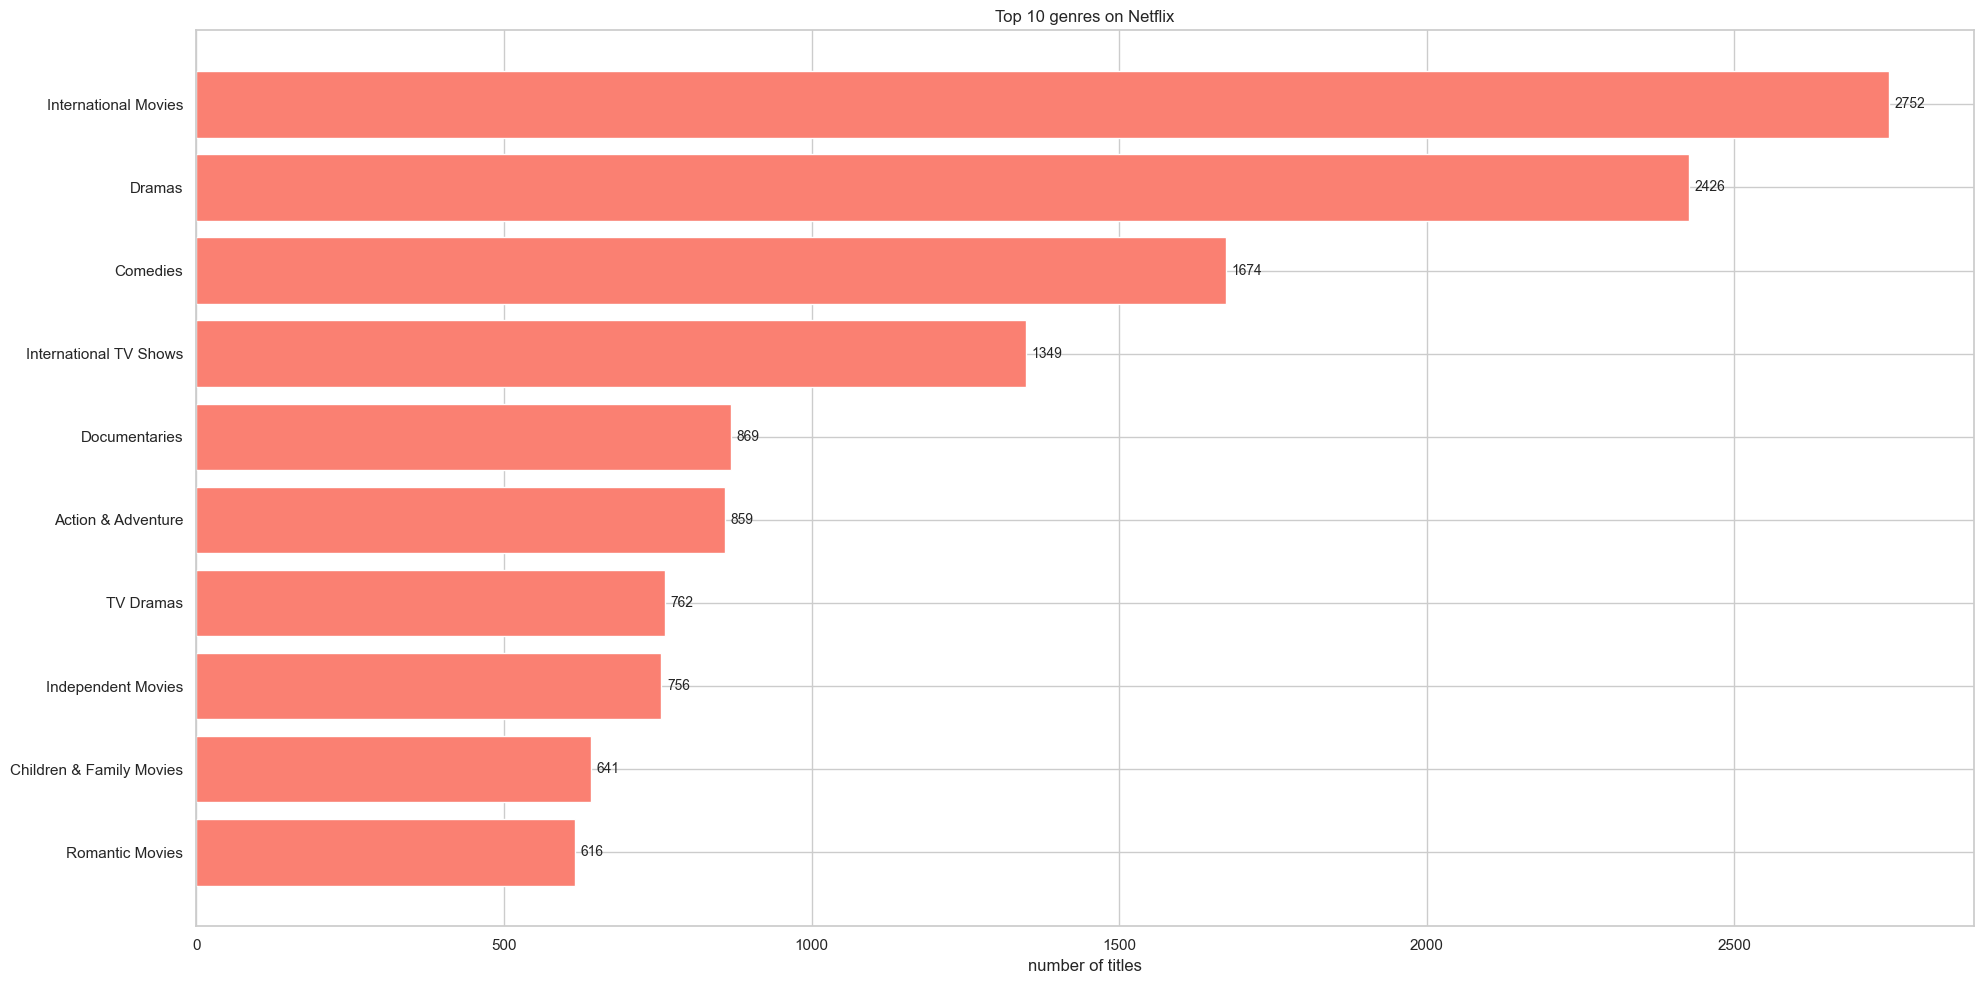

In [107]:
fig4,ax=plt.subplots(figsize=(20,10))
bars=ax.barh(genres.index[::-1],genres.values[::-1],color='salmon')
ax.bar_label(bars, padding=4,fontsize=10)
ax.set_title('Top 10 genres on Netflix')
ax.set_xlabel("number of titles")
plt.tight_layout()
plt.show()

### Observation

- International Movies are  highly represented.
- Drama-related categories appear frequently.
- Genre diversity is evident across the platform.

### Insight

Netflix emphasizes broad audience appeal by investing heavily in International movies, drama and Entertainment-focused genres.

## Analysis 5: Genre Trends Over Time

### Question

How has Netflix's content library grown over the years?

### Objective

To analyze trends in content additions and identify periods of rapid expansion

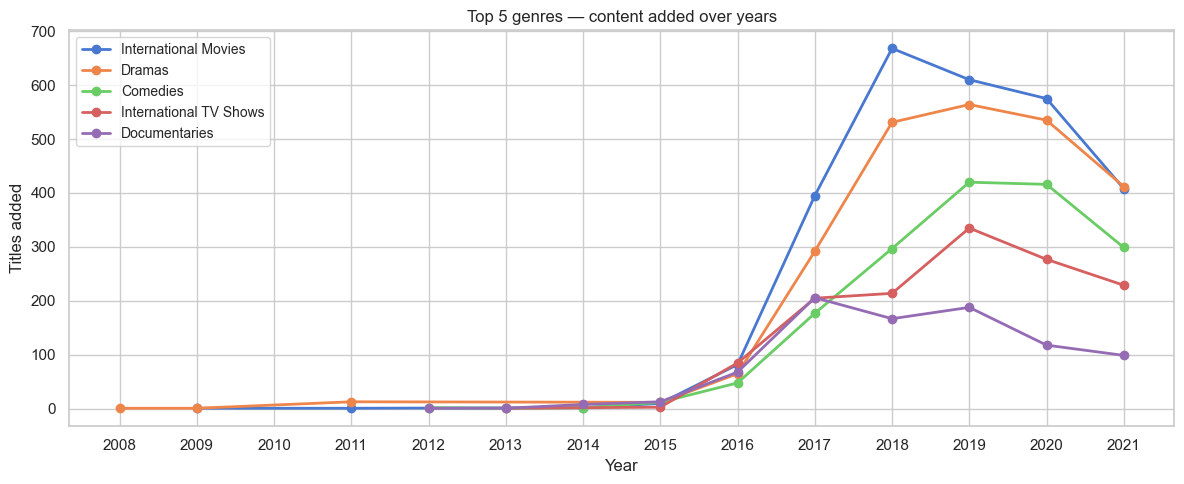

In [108]:
genre_df = df.copy()
genre_df = genre_df.dropna(subset=['year_added'])

genre_df = genre_df.assign(
    genre=genre_df['listed_in'].str.split(',')
).explode('genre')
genre_df['genre'] = genre_df['genre'].str.strip()

top5_genres = genre_df['genre'].value_counts().head(5).index.tolist()

genre_year = (
    genre_df[genre_df['genre'].isin(top5_genres)]
    .groupby(['year_added', 'genre'])
    .size()
    .reset_index(name='count')
)

fig, ax = plt.subplots(figsize=(12, 5))
for g in top5_genres:
    sub = genre_year[genre_year['genre'] == g]
    ax.plot(sub['year_added'], sub['count'], marker='o', label=g, linewidth=2)

ax.set_title('Top 5 genres — content added over years')
ax.set_xlabel('Year')
ax.set_ylabel('Titles added')
ax.legend(loc='upper left', fontsize=10)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.tight_layout()
plt.show()

### Observation

- Netflix experienced significant growth in content additions after 2015.
- The number of titles added peaked around 2018–2019.
- Recent years show a stabilization in content additions.

### Insight

The rapid growth phase reflects Netflix's aggressive expansion strategy and increasing investment in content acquisition.

## Analysis 6: Monthly Content Addition Pattern

### Question

Are there specific months during which Netflix adds more content?

### Objective

To identify seasonal patterns in content additions.

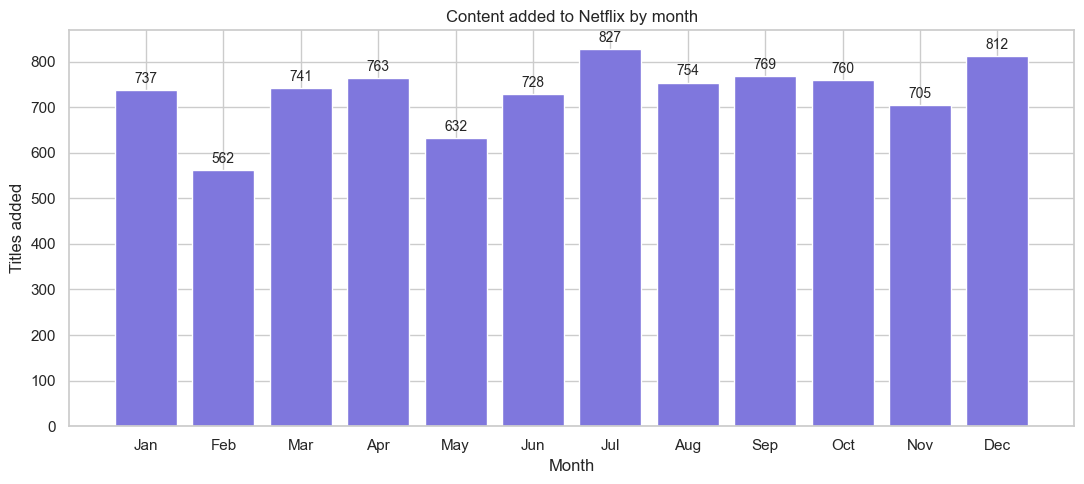

In [109]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

monthly = (
    df.groupby('month_name')
    .size()
    .reindex(month_order)
)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(monthly.index, monthly.values, color='#7F77DD', edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_title('Content added to Netflix by month')
ax.set_xlabel('Month')
ax.set_ylabel('Titles added')
plt.tight_layout()
plt.show()

### Observation

- Certain months show noticeably higher content additions.
- Content uploads are not evenly distributed throughout the year.
- Seasonal spikes can be observed.

### Insight

Netflix may strategically release content during periods of higher user engagement and viewing activity.

## Analysis 7: Correlation Analysis Using Heatmap

### Question

Are there any significant relationships between the numerical features in the Netflix dataset?

### Objective

To identify correlations between numerical variables and understand how different features relate to each other.

### Method

A correlation matrix is computed and visualized using a heatmap. The heatmap displays correlation coefficients ranging from -1 to 1:

- 1 indicates a perfect positive relationship.
- -1 indicates a perfect negative relationship.
- 0 indicates no linear relationship.

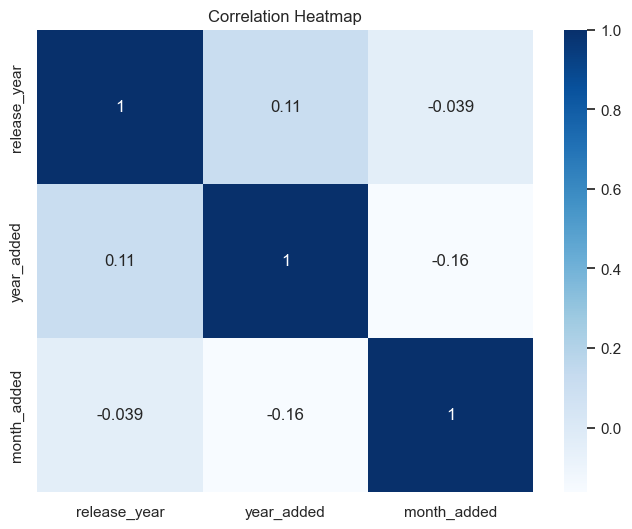

In [110]:
numeric_cols = ['release_year','year_added','month_added']

plt.figure(figsize=(8,6))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='Blues'
)
plt.title("Correlation Heatmap")
plt.show()

### Observation

- Most correlations are weak.
- Release Year and Year Added show a slight positive relationship (0.11).
- Month Added has little to no correlation with the other variables.

### Insight

The weak correlations suggest that Netflix's content acquisition strategy is influenced by multiple independent factors rather than a single dominant variable. 

In [111]:
print("=" * 50)
print("NETFLIX EDA — KEY FINDINGS")
print("=" * 50)

print(f"\n Total titles analysed : {len(df):,}")
print(f" Movies                : {len(movies):,} ({len(movies)/len(df)*100:.1f}%)")
print(f" TV Shows              : {len(shows):,} ({len(shows)/len(df)*100:.1f}%)")
print(f"\n Most common rating    : {df['rating'].value_counts().index[0]}")
print(f" Top country           : {country_counts.index[0]}")
print(f" Top genre             : {genres.index[0]}")
print(f" Avg movie duration    : {movies['duration_min'].mean():.0f} minutes")
print(f" Year with most adds   : {int(df['year_added'].value_counts().index[0])}")
print(f" Best month to add     : {df.groupby('month_name').size().reindex(month_order).idxmax()}")

NETFLIX EDA — KEY FINDINGS

 Total titles analysed : 8,790
 Movies                : 6,126 (69.7%)
 TV Shows              : 2,664 (30.3%)

 Most common rating    : TV-MA
 Top country           : United States
 Top genre             : International Movies
 Avg movie duration    : 100 minutes
 Year with most adds   : 2019
 Best month to add     : Jul


# Final Conclusion

## Key Findings

1. Movies dominate Netflix's catalog.
2. TV-MA is the most common rating.
3. USA contributes the most content.
4. International Movies are highly represented.
5. Netflix saw rapid expansion after 2015.

# Recommendations

- Expand investment in high-performing international content markets.
- Continue balancing Movies and TV Shows to cater to diverse audience preferences.
- Explore opportunities in growing genres with increasing popularity trends.
- Maintain a mix of recent and classic titles to maximize audience engagement.